# 🎭 Sentiment Analysis with HuggingFace

Use a pre-trained **DistilBERT** model to classify IMDB movie reviews as positive or negative.

In [1]:
!pip install transformers datasets torch scikit-learn matplotlib -q

# 1. IMDB dataset
50k movie reviews labelled positive or negative.
Only 500 samples from the test split so it runs fast

In [2]:
import pandas as pd

df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/test-00000-of-00001.parquet")
df = df.sample(500, random_state=42).reset_index(drop=True)

texts  = df['text'].tolist()
labels = df['label'].tolist()

print(f"Loaded {len(df)} samples")
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 500 samples


,text,label
0,I could not believe how terrible and boring th...,0
1,I rented Boogie Nights last week and I could t...,1
2,"First off, this movie is not near complete, my...",0
3,I watched this mini in the early eighties. Sam...,1
4,This movie was never intended as a big-budget ...,1


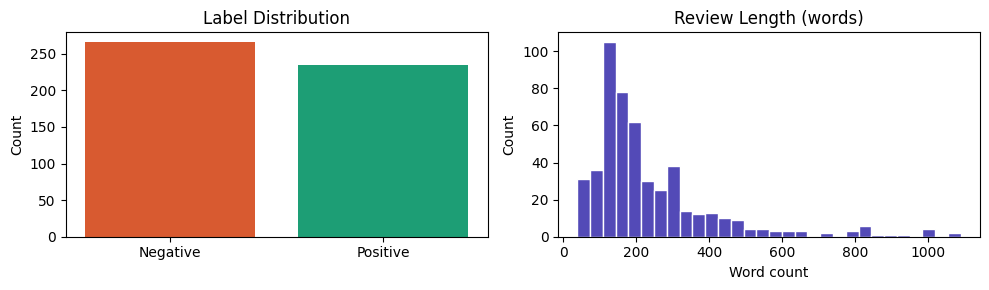

Average review length = 236 words
Longest review = 1090 words


In [6]:
import matplotlib.pyplot as plt

labels = df['label']
texts  = df['text']

pos = (labels == 1).sum()
neg = (labels == 0).sum()

# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].bar(['Negative', 'Positive'], [neg, pos], color=['#D85A30', '#1D9E75'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')

# Review length distribution
lengths = [len(t.split()) for t in texts]
axes[1].hist(lengths, bins=30, color='#534AB7', edgecolor='white')
axes[1].set_title('Review Length (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Average review length = {sum(lengths)//len(lengths)} words')
print(f'Longest review = {max(lengths)} words')

Note: **DistilBERT** is a smaller, faster version of BERT

In [7]:
!pip install -q sympy==1.13.3

In [8]:
from transformers import pipeline

classifier = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)

# Quick test
test = [
    'This movie was absolutely brilliant, loved every second.',
    'Terrible film. Worst two hours of my life.',
    'It was okay I guess, not great but not awful either.'
]
for t, r in zip(test, classifier(test)):
    print(f'{r["label"]:10} ({r["score"]:.2%}) = {t}')

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

POSITIVE   (99.99%) = This movie was absolutely brilliant, loved every second.
NEGATIVE   (99.98%) = Terrible film. Worst two hours of my life.
POSITIVE   (89.17%) = It was okay I guess, not great but not awful either.


# 2. Run inference

In [10]:
print('Running inference...')
results = classifier(texts.tolist(), batch_size=32)

predictions = [1 if r['label'] == 'POSITIVE' else 0 for r in results]
scores      = [r['score'] for r in results]

print('Done.')

Running inference...
Done.


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(labels, predictions)
print(f'Accuracy: {acc:.2%}\n')
print(classification_report(labels, predictions, target_names=['Negative', 'Positive']))

Accuracy: 89.00%

              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90       266
    Positive       0.89      0.87      0.88       234

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



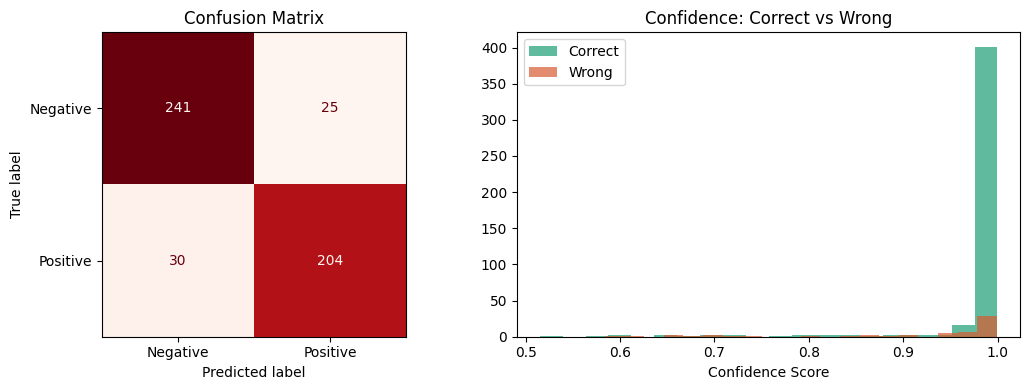

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Confusion Matrix')

# Confidence distribution
correct   = [scores[i] for i in range(len(labels)) if labels[i] == predictions[i]]
incorrect = [scores[i] for i in range(len(labels)) if labels[i] != predictions[i]]

axes[1].hist(correct,   bins=20, alpha=0.7, color='#1D9E75', label='Correct')
axes[1].hist(incorrect, bins=20, alpha=0.7, color='#D85A30', label='Wrong')
axes[1].set_title('Confidence: Correct vs Wrong')
axes[1].set_xlabel('Confidence Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()



# 3. Q: What kinds of reviews fool the model?

In [18]:
label_map = {0: 'Negative', 1: 'Positive'}

mistakes = [
    (texts[i], labels[i], predictions[i], scores[i])
    for i in range(len(labels))
    if labels[i] != predictions[i]
]

print(f'Total mistakes: {len(mistakes)} / 500\n')
print()

for text, true, pred, score in mistakes[:8]:
    print(f'\nTrue: {label_map[true]:10} | Predicted: {label_map[pred]:10} | Confidence: {score:.2%}')
    print(f'Review: {text[:200]}...')

Total mistakes: 55 / 500



True: Positive   | Predicted: Negative   | Confidence: 99.68%
Review: I just watched it for the second time today and I must say with all my heart it is about damn time they made a movie about us as people not as spiritual beings. Such a waste of human life as this stor...

True: Negative   | Predicted: Positive   | Confidence: 99.52%
Review: I've read through a lot of the comments here about how this movie sticks to the book.. I don't think any of them have actually read it. Edgar Rice wrote about a dangerous African Jungle and Apes were ...

True: Positive   | Predicted: Negative   | Confidence: 90.39%
Review: This was very funny, even if it fell apart a little at the end. Does not go overboard with homage after to Hitchcock - Owen (Danny DeVito) was lucky he had "Strangers on A Train" playing at the local ...

True: Positive   | Predicted: Negative   | Confidence: 86.60%
Review: The movie was very good. I'm an avid mystery fan and I usually figure out who

## 4. Try your own review

In [22]:
MyReview = "The acting was amazing but the plot was not bad."

result = classifier(MyReview)[0]
print(f'Sentiment : {result["label"]}')
print(f'Confidence = {result["score"]:.2%}')

Sentiment : POSITIVE
Confidence = 99.81%
